In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [17]:
scen=pd.read_csv('/Users/seasonliew/Downloads/Book1.csv', header=None).values
lin_a=100
lin_b=-400
scen=lin_a*scen+lin_b

In [28]:
ia_c=100
ia_o=0
th_c=0
th_o=0
mta_c=0
mta_o=0
roundoff=0.0001

In [29]:
def roundofffun(x,a):
    mod1=  x % a
    if(mod1<a/2):
        result=x-mod1
    else:
        result=x+(a-mod1)
    return result  

vmb=np.zeros((scen.shape[0],scen.shape[1]))
for j in range(0,vmb.shape[1]):
    path=scen[:,j]
    ivmb=ia_c-ia_o
    vmb[0,j]=ivmb
    for i in range(0,vmb.shape[0]-1):
        mtm=path[i]
        VM_exchange=max(mtm+(ia_c-ia_o)-th_c,0) - max(-th_o-(mtm + ia_c-ia_o),0)-vmb[i,j]
        if ((-mta_o<VM_exchange) & (VM_exchange<mta_c)):
            VM_exchange=0
        VM_exchange_round=roundofffun(VM_exchange,roundoff)
        vmb[i+1,j]=VM_exchange_round+vmb[i,j]



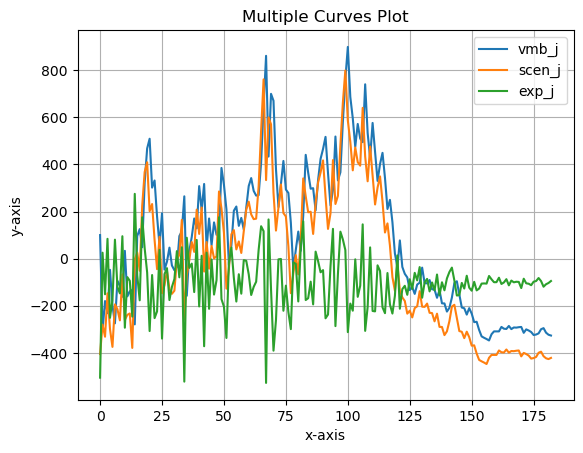

In [30]:
j=2
vmb_j=vmb[:,j]
scen_j=scen[:,j]
exp_j=scen_j-vmb_j
# Example data
x = list(range(0,scen.shape[0]))
# Plotting
plt.plot(x, vmb_j, label='vmb_j')
plt.plot(x, scen_j, label='scen_j')
plt.plot(x, exp_j, label='exp_j')

# Customizing the plot
plt.xlabel('x-axis')
plt.ylabel('y-axis')
plt.title('Multiple Curves Plot')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()
